In [5]:
import sys
import os

# Add parent directory to path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve

sns.set_theme(style="whitegrid")

# Load featured dataset and prepare test split
df = pd.read_csv("../data/processed/featured_data.csv")
df['is_high_risk'] = (df['risk_score'] > 50).astype(int)

exclude_cols = ['timestamp', 'segment_id', 'road_type', 'risk_score', 'is_high_risk']
feature_cols = [col for col in df.select_dtypes(include=[np.number]).columns if col not in exclude_cols]

X = df[feature_cols]
y = df['is_high_risk']
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Load trained models from Phase 7 using correct root path relative to notebooks folder
models = {
    "Logistic Regression": joblib.load("../models/baseline_logistic_regression.joblib"),
    "Random Forest": joblib.load("../models/baseline_random_forest.joblib"),
    "XGBoost": joblib.load("../models/baseline_xgboost.joblib")
}

print("[SUCCESS] Test split and models loaded successfully!")

[SUCCESS] Test split and models loaded successfully!


In [6]:
evaluation_results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    evaluation_results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "ROC-AUC": round(roc_auc, 4)
    })

results_df = pd.DataFrame(evaluation_results)
display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.95,0.9167,0.7333,0.8148,0.9827
1,Random Forest,0.94,0.8462,0.7333,0.7857,0.9593
2,XGBoost,0.95,0.8333,0.8333,0.8333,0.9724


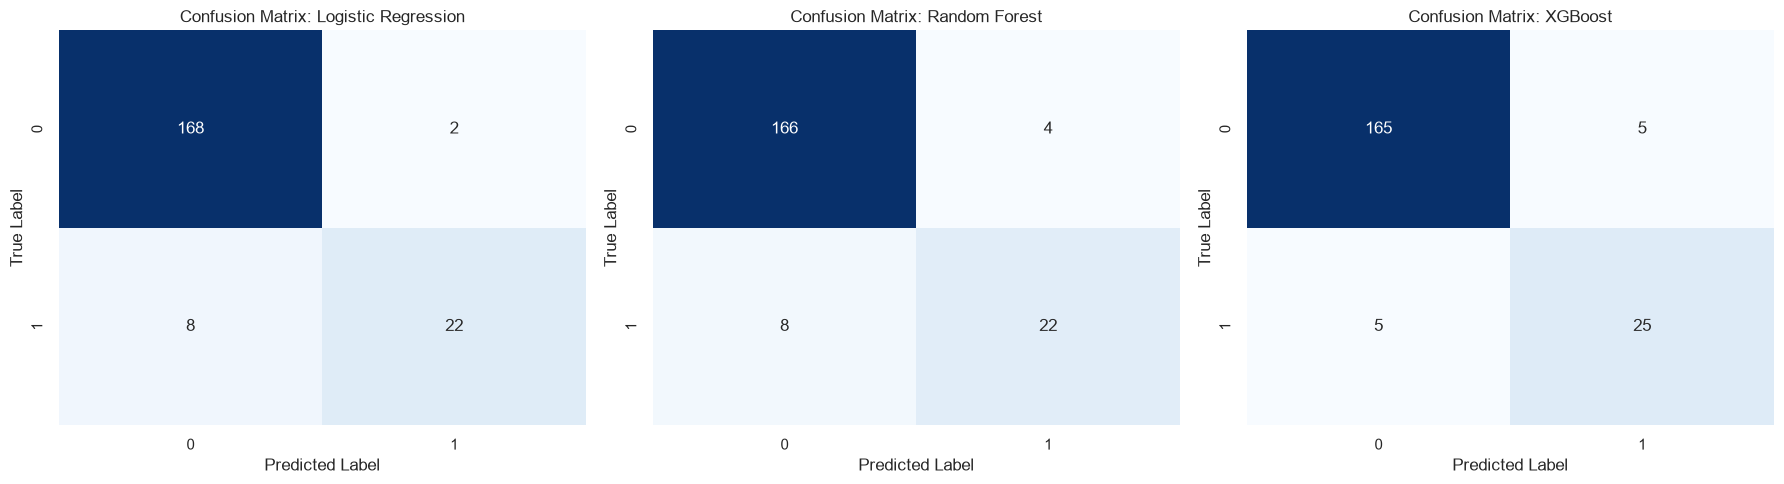

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
    axes[idx].set_title(f"Confusion Matrix: {name}")
    axes[idx].set_xlabel("Predicted Label")
    axes[idx].set_ylabel("True Label")

plt.tight_layout()
plt.show()

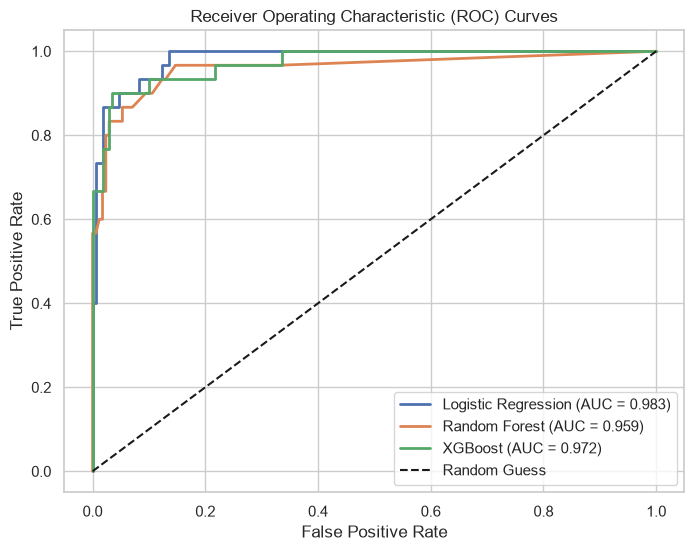

In [8]:
plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})", linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curves")
plt.legend(loc="lower right")
plt.show()